# Sucursal Bancaria
Una pequeña sucursal de un banco tiene dos empleados, uno para los pagos y otro para los cobros. Los clientes llegan a cada caja siguiendo una distribución de Poisson con una media de 20/hora. (el total de llegada al banco es de 40/hora). El tiempo de servicio de cada empleado es una negativa exponencial de media 2 minutos. El encargado de la sección está pensando hacer un cambio en que los dos operarios puedan hacer tanto pagos como cobros para evitar situaciones en que una cola está llena y la otra parada. Sin embargo, se estima que cuando los empleados se encarguen de las dos cosas el tiempo de servicio aumentará a una media de 2,4 minutos. Compara el sistema que se emplea ahora con el propuesto, calculando el total de gente en el banco, el tiempo medio que pasaría un cliente en el banco hasta que es atendido, la probabilidad de que un cliente espere más de cinco minutos y el tiempo medio que están parados los empleados.

In [33]:
import simpy
import random
import statistics
import matplotlib.pyplot as plt
import numpy as np
import os

In [34]:
# Parámetros
SIM_TIME = 10 * 60  # 10 horas en minutos
SEED = 42
random.seed(SEED)

In [35]:
# Sistema 1 (dos colas independientes)
ARRIVAL_RATE_S1 = 20 / 60
SERVICE_MEAN_S1 = 2

def simular_sistema1():
    resultados = {}
    datos = {}
    for caja in [1, 2]:
        env = simpy.Environment()
        servidor = simpy.Resource(env, capacity=1)
        tiempos_espera = []
        tiempos_servicio = []
        clientes = []

        def proceso_cliente(env, cliente, servidor):
            with servidor.request() as req:
                yield req
                inicio = env.now
                espera = inicio - cliente["llegada"]
                tiempos_espera.append(espera)
                tiempo_servicio = random.expovariate(1.0 / SERVICE_MEAN_S1)
                tiempos_servicio.append(tiempo_servicio)
                yield env.timeout(tiempo_servicio)
                cliente["salida"] = env.now

        def generador_clientes(env):
            while env.now < SIM_TIME:
                yield env.timeout(random.expovariate(ARRIVAL_RATE_S1))
                cliente = {"llegada": env.now}
                clientes.append(cliente)
                env.process(proceso_cliente(env, cliente, servidor))

        env.process(generador_clientes(env))
        env.run(until=SIM_TIME)

        tiempos_totales = [c["salida"] - c["llegada"] for c in clientes if "salida" in c]
        total_servicio = sum(tiempos_servicio)
        idle_time = SIM_TIME - total_servicio

        datos[f"Caja_{caja}"] = {
            "num_clientes": len(clientes),
            "promedio_total": statistics.mean(tiempos_totales),
            "prob_espera_mas_5": sum(1 for w in tiempos_espera if w > 5) / len(tiempos_espera),
            "idle_time": idle_time
        }

    total_clientes = datos["Caja_1"]["num_clientes"] + datos["Caja_2"]["num_clientes"]
    promedio_total = (
        datos["Caja_1"]["promedio_total"] * datos["Caja_1"]["num_clientes"] +
        datos["Caja_2"]["promedio_total"] * datos["Caja_2"]["num_clientes"]
    ) / total_clientes
    prob_espera_mas_5 = (
        datos["Caja_1"]["prob_espera_mas_5"] * datos["Caja_1"]["num_clientes"] +
        datos["Caja_2"]["prob_espera_mas_5"] * datos["Caja_2"]["num_clientes"]
    ) / total_clientes
    promedio_idle = (datos["Caja_1"]["idle_time"] + datos["Caja_2"]["idle_time"]) / 2.0
    lambda_total = 2 * ARRIVAL_RATE_S1
    L_total = lambda_total * promedio_total

    resultados["Sistema1"] = {
        "total_clientes": total_clientes,
        "promedio_tiempo_total": promedio_total,
        "prob_espera_mas_5": prob_espera_mas_5,
        "promedio_idle_empleado": promedio_idle,
        "L_total": L_total
    }
    return resultados


In [36]:
# Sistema 2 (una sola cola, dos servidores)
ARRIVAL_RATE_S2 = 40 / 60
SERVICE_MEAN_S2 = 2.4

def simular_sistema2():
    env = simpy.Environment()
    servidor = simpy.Resource(env, capacity=2)
    tiempos_espera = []
    tiempos_servicio = []
    clientes = []

    def proceso_cliente(env, cliente, servidor):
        with servidor.request() as req:
            yield req
            inicio = env.now
            espera = inicio - cliente["llegada"]
            tiempos_espera.append(espera)
            tiempo_servicio = random.expovariate(1.0 / SERVICE_MEAN_S2)
            tiempos_servicio.append(tiempo_servicio)
            yield env.timeout(tiempo_servicio)
            cliente["salida"] = env.now

    def generador_clientes(env):
        while env.now < SIM_TIME:
            yield env.timeout(random.expovariate(ARRIVAL_RATE_S2))
            cliente = {"llegada": env.now}
            clientes.append(cliente)
            env.process(proceso_cliente(env, cliente, servidor))

    env.process(generador_clientes(env))
    env.run(until=SIM_TIME)

    tiempos_totales = [c["salida"] - c["llegada"] for c in clientes if "salida" in c]
    total_servicio = sum(tiempos_servicio)
    idle_total = (2 * SIM_TIME) - total_servicio
    promedio_idle = idle_total / 2.0
    promedio_total = statistics.mean(tiempos_totales)
    L_total = ARRIVAL_RATE_S2 * promedio_total

    return {
        "total_clientes": len(clientes),
        "promedio_tiempo_total": promedio_total,
        "prob_espera_mas_5": sum(1 for w in tiempos_espera if w > 5) / len(tiempos_espera),
        "promedio_idle_empleado": promedio_idle,
        "L_total": L_total
    }

In [37]:
# Simular
res_s1 = simular_sistema1()
res_s2 = simular_sistema2()


In [38]:
# Comparar
labels = ['Sistema 1 (M/M/1 x 2)', 'Sistema 2 (M/M/2)']
tiempos_totales = [res_s1['Sistema1']['promedio_tiempo_total'], res_s2['promedio_tiempo_total']]
prob_espera_mas_5 = [res_s1['Sistema1']['prob_espera_mas_5'], res_s2['prob_espera_mas_5']]
idle_times = [res_s1['Sistema1']['promedio_idle_empleado'], res_s2['promedio_idle_empleado']]
total_L = [res_s1['Sistema1']['L_total'], res_s2['L_total']]

x = np.arange(len(labels))
width = 0.3



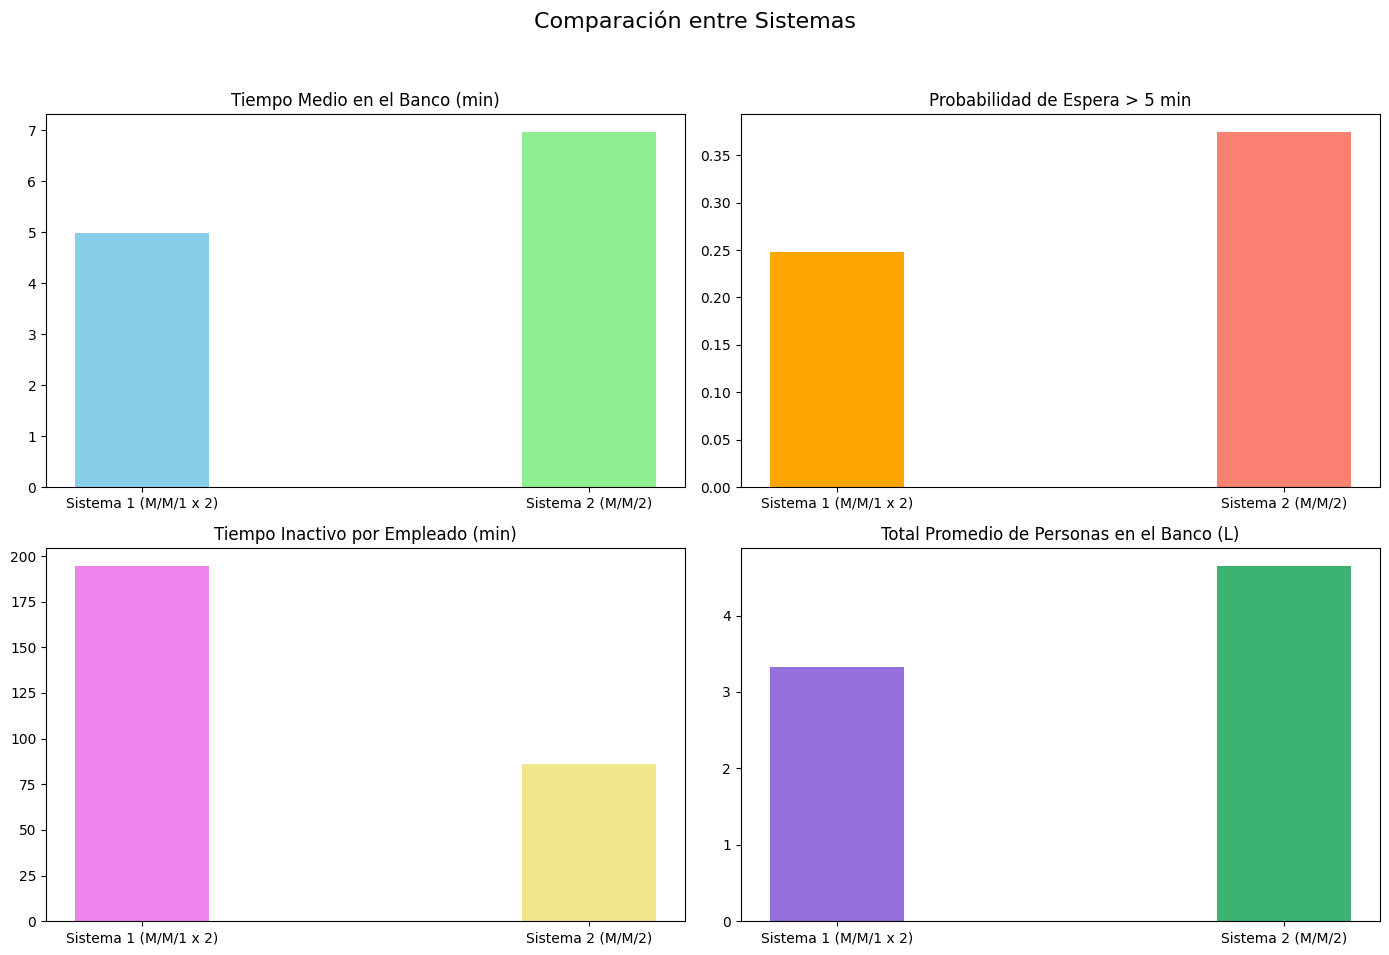

In [39]:
import os

# Crear carpeta si no existe
os.makedirs("../graphs", exist_ok=True)

# Verificar si ya existe la imagen
ruta_guardado = "../graphs/comparacion.png"
existe = os.path.exists(ruta_guardado)

# Datos
labels = ['Sistema 1 (M/M/1 x 2)', 'Sistema 2 (M/M/2)']
tiempos_totales = [res_s1['Sistema1']['promedio_tiempo_total'], res_s2['promedio_tiempo_total']]
prob_espera_mas_5 = [res_s1['Sistema1']['prob_espera_mas_5'], res_s2['prob_espera_mas_5']]
idle_times = [res_s1['Sistema1']['promedio_idle_empleado'], res_s2['promedio_idle_empleado']]
total_L = [res_s1['Sistema1']['L_total'], res_s2['L_total']]

x = np.arange(len(labels))
width = 0.3

# Crear figura
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparación entre Sistemas', fontsize=16)

axs[0, 0].bar(x, tiempos_totales, width, color=['skyblue', 'lightgreen'])
axs[0, 0].set_title('Tiempo Medio en el Banco (min)')
axs[0, 0].set_xticks(x)
axs[0, 0].set_xticklabels(labels)

axs[0, 1].bar(x, prob_espera_mas_5, width, color=['orange', 'salmon'])
axs[0, 1].set_title('Probabilidad de Espera > 5 min')
axs[0, 1].set_xticks(x)
axs[0, 1].set_xticklabels(labels)

axs[1, 0].bar(x, idle_times, width, color=['violet', 'khaki'])
axs[1, 0].set_title('Tiempo Inactivo por Empleado (min)')
axs[1, 0].set_xticks(x)
axs[1, 0].set_xticklabels(labels)

axs[1, 1].bar(x, total_L, width, color=['mediumpurple', 'mediumseagreen'])
axs[1, 1].set_title('Total Promedio de Personas en el Banco (L)')
axs[1, 1].set_xticks(x)
axs[1, 1].set_xticklabels(labels)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Guardar si no existe
if not existe: fig.savefig(ruta_guardado)
plt.show()


In [40]:
# Mostrar métricas por consola
print("Metricas del sistema 1 (Dos colas M/M/1 x 2)")
for k, v in res_s1['Sistema1'].items():
    print(f"- {k.replace('_', ' ').capitalize()}: {v:.2f}")

print("\nMetricas del sistema 2 (Cola única M/M/2)")
for k, v in res_s2.items():
    print(f"- {k.replace('_', ' ').capitalize()}: {v:.2f}")

Metricas del sistema 1 (Dos colas M/M/1 x 2)
-Total clientes: 395.00
-Promedio tiempo total: 4.98
-Prob espera mas 5: 0.25
-Promedio idle empleado: 194.61
-L total: 3.32

Metricas del sistema 2 (Cola única M/M/2)
-Total clientes: 412.00
-Promedio tiempo total: 6.98
-Prob espera mas 5: 0.38
-Promedio idle empleado: 85.87
-L total: 4.65
